# 4_DE_plot.R

In [24]:
#basic settings
wd="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/results/wilcox_de_humanxeno/Transplant_vs_control"
setwd(wd)

#load required packages
library(ggplot2)
library(stringr)
library(dplyr)
library(ggrepel)
library(RColorBrewer) 

output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/plot/"

colors_ordered <- c(
  "#8dd3c7",  # Red
  "#4A7E9A",  # Orange
  "#bebada",  # Yellow
  "#80b1d3",  # Teal/Green
  "#b3de69",  # Cyan
  "#ffed6f",  # Blue
  "#b15928"
)

In [25]:
#input files - ldsc results 
file_list=list.files(pattern="*_wilcox_de.csv")
length(file_list)
file_list=file_list[which(!str_detect(file_list, "NotAssigned") & 
                          !str_detect(file_list, "doublets") & 
                          !str_detect(file_list, "Atrial_Cardiomyocyte") &
                          !str_detect(file_list, "Ventricular_Cardiomyocyte")
                         )
                   ]

[1] 7

In [28]:
celltype=c()
for (i in 1:length(file_list))
{
    celltype=append(celltype, strsplit(file_list[i], "_wilcox_de.csv")[[1]])
}

df=data.frame(matrix(NA,ncol=10, nrow=1))
for (i in 1:length(file_list))
{
    deg_table=read.table(file=paste0(celltype[i], "_wilcox_de.csv"), sep="\t", header=T)
    deg_table$label=ifelse(deg_table$p_val_adj<0.05 & abs(deg_table$avg_log2FC) > 5, "adjust P-val<0.05", "adjust P-val>=0.05")
    deg_table$celltype=rep(i, times=length(rownames(deg_table)))
    deg_table$celltype_name=rep(celltype[i], times=length(rownames(deg_table)))
    
    #mark top 10 significant genes
    top10=rownames(deg_table)[1:3]
    deg_table$size=case_when(!(rownames(deg_table) %in% top10)~ 1, rownames(deg_table) %in% top10 ~ 2)
    deg_table$geneID=rownames(deg_table)
    
    colnames(df)=colnames(deg_table)
    df=rbind(df, deg_table)
}
df_plot=df[-1,]
df_plot=df_plot[which(!str_detect(df_plot$geneID, "ENSG")), ]

In [29]:
celltype

[1] "CM"                       "EC"                      
[3] "Endocardial_Lymphatic_EC" "Fibroblasts"             
[5] "Neuronal_cells"           "Pericyte"                
[7] "SMC"

In [30]:
celltype_label=c(
"",
"",
"",
"",
"",
"",
""
)

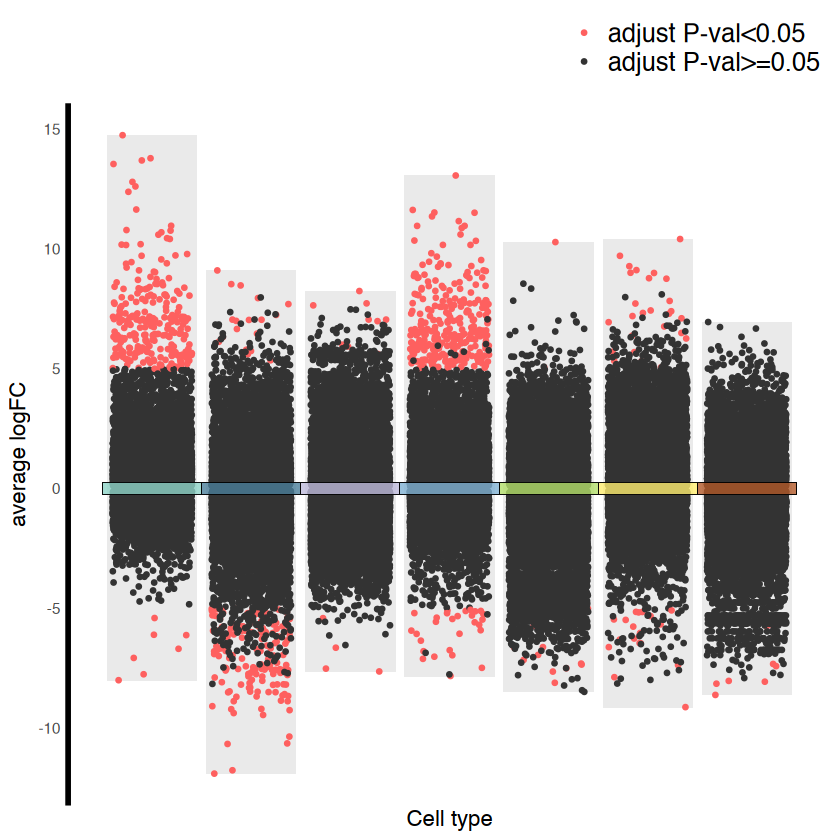

In [31]:
max_logfc <- c()
min_logfc <- c()
for (i in 1:max(df_plot$celltype)) {
    max_logfc <- append(max_logfc, max(df_plot$avg_log2FC[which(df_plot$celltype == i)]))
    min_logfc <- append(min_logfc, min(df_plot$avg_log2FC[which(df_plot$celltype == i)]))
}

dfbar <- data.frame(x = c(1:max(df_plot$celltype)),
                   y = max_logfc)

dfbar1 <- data.frame(x = c(1:max(df_plot$celltype)),
                    y = min_logfc)

p1 <- ggplot() +
  geom_col(data = dfbar,
           mapping = aes(x = x, y = y),
           fill = "#dcdcdc", alpha = 0.6) +
  geom_col(data = dfbar1,
           mapping = aes(x = x, y = y),
           fill = "#dcdcdc", alpha = 0.6) +
  geom_jitter(data = df_plot,
              aes(x = celltype, y = avg_log2FC, color = label),
              size = 0.85,
              width = 0.4)

num <- max(df_plot$celltype)
# Assuming 'colors_ordered' is a vector of color names with length 'num'
# It's better to add the colors to the dataframe directly
dfcol <- data.frame(x = c(1:num),
                    y = 0,
                    label = c(1:num),
                    tile_color = colors_ordered) 

p2 <- p1 + geom_tile(
  data = dfcol,
  aes(x = x, y = y, fill = tile_color), # Map the color column
  height = 0.5,
  color = "black",
  alpha = 0.8,
  show.legend = FALSE
) +
scale_fill_identity() # Use the color values directly

# The final plot code WITHOUT the geom_text_repel layer
p3 <- p2 +
  scale_color_manual(name = NULL,
                     values = c("#FE605F", "grey20")) +
  labs(x = "Cell type", y = "average logFC") +
  geom_text(data = dfcol,
            aes(x = x, y = y, label = celltype_label),
            size = 3,
            color = "white") +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 13,
                              color = "black",
                              face = "bold"),
    axis.line.y = element_line(color = "black",
                               linewidth = 1.2),
    axis.line.x = element_blank(),
    axis.text.x = element_blank(),
    panel.grid = element_blank(),
    legend.position = "top",
    legend.direction = "vertical",
    legend.justification = c(1, 0),
    legend.text = element_text(size = 15)
  ) 

# Display the final plot
print(p3)

In [32]:
# Define the necessary vectors and dataframes (assuming 'df_plot', 'colors_ordered', and 'celltype_label' are defined elsewhere)
max_logfc <- c()
min_logfc <- c()
for (i in 1:max(df_plot$celltype)) {
    max_logfc <- append(max_logfc, max(df_plot$avg_log2FC[which(df_plot$celltype == i)]))
    min_logfc <- append(min_logfc, min(df_plot$avg_log2FC[which(df_plot$celltype == i)]))
}

dfbar <- data.frame(x = c(1:max(df_plot$celltype)),
                   y = max_logfc)

dfbar1 <- data.frame(x = c(1:max(df_plot$celltype)),
                    y = min_logfc)

num <- max(df_plot$celltype)

# Create a sample 'colors_ordered' and 'celltype_label' for completeness (REPLACE with your actual data)
# Example dummy data for illustration:
# colors_ordered <- sample(c("#8dd3c7", "#4A7E9A", "#bebada", "#80b1d3", "#fdb462"), size = num, replace = TRUE)
# celltype_label <- paste("CT", 1:num, sep="")

dfcol <- data.frame(x = c(1:num),
                    y = 0,
                    label = c(1:num),
                    tile_color = colors_ordered,
                    celltype_label = celltype_label) # Combine necessary columns

# 1. Create the ggplot object (p3)
p1 <- ggplot() +
  geom_col(data = dfbar,
           mapping = aes(x = x, y = y),
           fill = "#dcdcdc", alpha = 0.6) +
  geom_col(data = dfbar1,
           mapping = aes(x = x, y = y),
           fill = "#dcdcdc", alpha = 0.6) +
  geom_jitter(data = df_plot,
              aes(x = celltype, y = avg_log2FC, color = label),
              size = 0.85,
              width = 0.4)

p2 <- p1 + geom_tile(
  data = dfcol,
  aes(x = x, y = y, fill = tile_color),
  height = 0.5,
  color = "black",
  alpha = 0.8,
  show.legend = FALSE
) +
scale_fill_identity()

p3 <- p2 +
  scale_color_manual(name = NULL,
                     values = c("#FE605F", "grey20")) +
  labs(x = "Cell type", y = "average logFC") +
  geom_text(data = dfcol,
            aes(x = x, y = y, label = celltype_label),
            size = 3,
            color = "white") +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 13,
                              color = "black",
                              face = "bold"),
    axis.line.y = element_line(color = "black",
                               linewidth = 1.2),
    axis.line.x = element_blank(),
    axis.text.x = element_blank(),
    panel.grid = element_blank(),
    legend.position = "top",
    legend.direction = "vertical",
    legend.justification = c(1, 0),
    legend.text = element_text(size = 15)
  )

# 2. Save the plot as a PDF using ggsave()
ggsave(
    filename = "logFC_Bar_Jitter_Plot.pdf", 
    plot = p3, 
    device = "pdf", 
    # Adjust width and height in inches to prevent crowding/cropping
    width = 6, 
    height = 6, 
    units = "in"
)